# Detection & Analysis of Pre-SN Outburst Simulations

[View our paper here](https://iopscience.iop.org/article/10.3847/1538-4357/ad973d) for details on our cleaning and binning method, as well as our pre-SN outburst detection process!

## Settings 
### Load the config file and preset column names

In [1]:
# ==== User Settings ====

# Enter the config file name:
CONFIG_FILE = "config.ini"

# Enter the column name preset to use 
# (see config file for more; options: "atlas", "rubin", "tess"):
PRESET = "atlas"

# =======================

import sys, json
import numpy as np
import pandas as pd
from typing import Optional, List
import matplotlib.pyplot as plt

from download import load_config, make_dir_if_not_exists
from lightcurve import PresetColumnNames, Supernova, AveragedSupernova, LightCurve, SimDetecLightCurve, SimDetecSupernova
from plot import Plot, PlotLimits
from utils import load_json_config, reformat_dir, get_config_flags, get_inverse_mjd_ranges, hexstring_to_int, TEMPLATE_CHANGE_1_MJD, TEMPLATE_CHANGE_2_MJD
from generate_sim_table import parse_params, parse_colname_info, SimTables, get_sim_tables_output_dir, Param, Params, ListParam, RangeParam, LogRangeParam, RandomParam, RandomInRangeParam
from generate_detec_table import ContaminationTable, Model, SimDetecTable, SimDetecTables, EfficiencyTable, AtlasSimDetecLoop, get_detec_tables_output_dir

# load config
config = load_config(CONFIG_FILE)

# load preset
print(f"\nLoading '{PRESET}' preset column names from {CONFIG_FILE}...")
colnames = PresetColumnNames(config, PRESET)
print(colnames.__str__())


Loading config file at config.ini...

Loading 'atlas' preset column names from config.ini...
--- Required Columns ---
mjd: MJD
flux: uJy
dflux: duJy
--- Optional Columns ---
chisquare: chi/N
filt: F
mag: m
dmag: dm
ra: RA
dec: Dec
--- Extra Columns to Copy ---
x, y, maj, min, phi, apfit, mag5sig, Sky, Obs


### Load the light curves

In [2]:
# ==== User Settings ====

# Enter the target SN name:
TNSNAME = '2019vxm'

# Enter the path to the data directory that contains the ATClean-readable SN directories:
INPUT_DIR = config["dir"]["atclean_input"]

# Enter the path to the directory that contains cleaned and binned light curves, plots, and more:
OUTPUT_DIR = config["dir"]["output"]

# Automatically save the generated plots in this notebook?:
SAVE_PLOTS = False
# Enter the path to a directory to optionally save plots:
PLOTS_DIR = f'{OUTPUT_DIR}/{TNSNAME}/bump_analysis/plots'

# Enter the filter for this light curve:
FILT = 'tess' #'o' 

# Enter the SN's discovery date:
DISCOVERY_DATE = 58650.0

# Enter the size of the MJD bins (in days):
MJD_BIN_SIZE = 0.125 #1.0

# Enter the number of control light curves to load:
NUM_CONTROLS = 8 #7 #int(config["download"]["num_controls"])

# Edit the default color scheme here:
COLOR_SCHEME = {
    "sn_flux": {
        # ATLAS
        "o": "orange",
        "c": "cyan",
        # Rubin
        "u": "purple",
        "g": "green",
        "r": "salmon",
        "i": "indigo",
        "z": "brown",
        "y": "darkred",
        # TESS
        "tess": "plum",
    },
    "sn_flagged_flux": "red",
    "control_flux": "steelblue",
    "select_control_flux": "forestgreen",
    "face": "whitesmoke",
    "sn_fom": "deeppink",
    "control_fom": "cornflowerblue",
    "select_control_fom": "mediumblue",
}

# =======================

# make sure tnsname not attached to end of input and output dirs
INPUT_DIR = reformat_dir(INPUT_DIR, TNSNAME)
OUTPUT_DIR = reformat_dir(OUTPUT_DIR, TNSNAME)

print(f'SN {TNSNAME}, filter {FILT}', end='')
if not DISCOVERY_DATE is None:
    print(f', discovery date: {DISCOVERY_DATE}')
print(f'Output directory (load cleaned and binned light curves): {OUTPUT_DIR}/{TNSNAME}')
print(f'Plots directory (save plots): {PLOTS_DIR}')

# load cleaned light curves
sn = Supernova(colnames, tnsname=TNSNAME, mjd0=DISCOVERY_DATE, filt=FILT)
sn.load_all(OUTPUT_DIR, NUM_CONTROLS, cleaned=True)

# load binned light curves
avg_sn = SimDetecSupernova(colnames, tnsname=TNSNAME, mjdbinsize=MJD_BIN_SIZE, mjd0=DISCOVERY_DATE, filt=FILT)
avg_sn.load_all(OUTPUT_DIR, NUM_CONTROLS)

p = Plot(output_dir=PLOTS_DIR, color_scheme=COLOR_SCHEME)

config_flags = get_config_flags(config)

SN 2019vxm, filter tess, discovery date: 58650.0
Output directory (load cleaned and binned light curves): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm
Plots directory (save plots): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm/bump_analysis/plots

Loading SN light curve and 8 control light curves...
Successfully loaded SN light curve and 8 control light curves (control indices: [1, 2, 3, 4, 5, 6, 7, 8])

Loading averaged SN light curve and 8 averaged control light curves...
Successfully loaded averaged SN light curve and 8 averaged control light curves (control indices: [1, 2, 3, 4, 5, 6, 7, 8])
Using custom color scheme for plots

Searching config file for custom cuts...
Found 1


## Plot cleaned original and binned pre-SN light curves

Note that if there are no pre-MJD0 measurements, the entire light curve will be plotted.

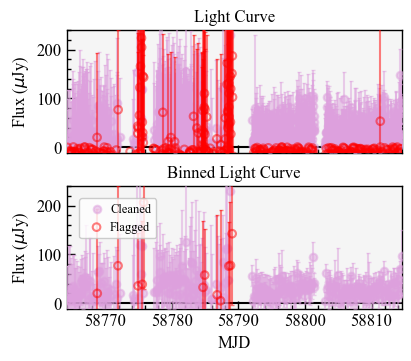

In [3]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_preSN(
    sn, 
    avg_sn, 
    config_flags,
    custom_lims=custom_lims,
    save=SAVE_PLOTS
)

## Plot all control light curves

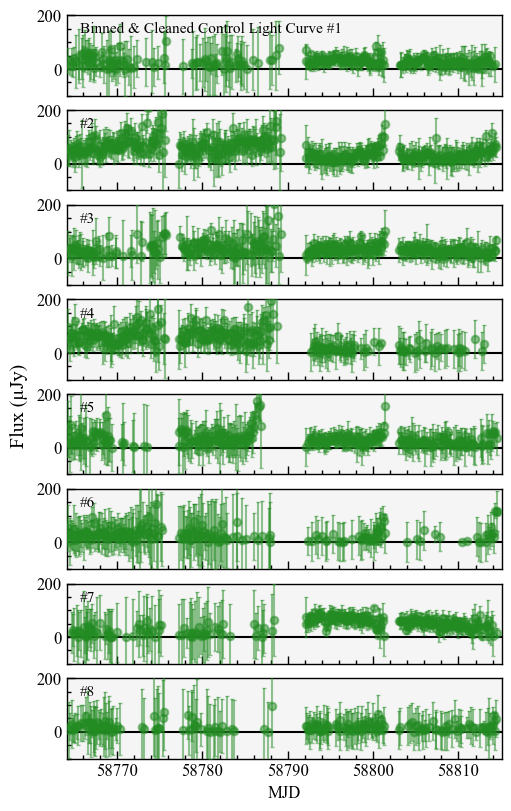

In [4]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = -100
YLIM_UPPER = 200

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_all_controls(
    avg_sn, 
    config_flags,
    custom_lims=custom_lims,
    two_columns=False,
    save=SAVE_PLOTS
)

## Plot binned pre-SN and control light curve

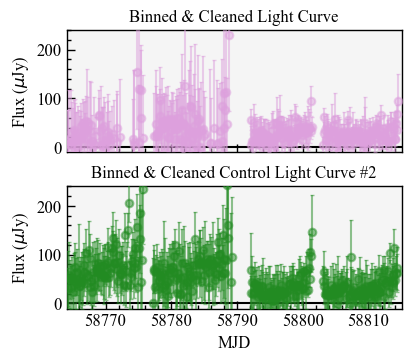

In [5]:
# ==== User Settings ====

# Enter the index of the control light curve to plot:
SELECT_CONTROL_INDEX = 2

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_binned_examples(
    avg_sn, 
    SELECT_CONTROL_INDEX, 
    config_flags,
    custom_lims=custom_lims, 
    save=SAVE_PLOTS
)

## Get detection limits w.r.t. contamination

We use the bisection method to calculate the best detection limits $\Sigma_{\text{FOM, limit}}$ for each $\sigma_{\text{kernel}}$ with respect to a target contamination value.

We measure contamination for a given $\sigma_{\text{kernel}}$ and its corresponding $\Sigma_{\text{FOM, limit}}$ by counting the number of false positives in the control light curves (where a single false positive is defined by a continuous sequence of $\Sigma_{\text{FOM}}$ above $\Sigma_{\text{FOM, limit}}$). We record two alternative measures of contamination for evaluating a certain $\Sigma_{\text{FOM, limit}}$:

1. the number of positive control light curves (default option)
2. the total number of false positives throughout all control light curve

#### Plot observation seasons

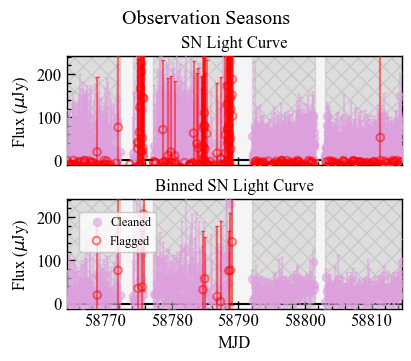

In [6]:
# ==== User Settings ====

# List the observation seasons 
# (set to empty list [] for the entire span of the light curve):
MJD_RANGES: List[List[int]] = [
    [58764.0625, 58772.1875],
    [58774.1875, 58775.8125],
    [58777.1875, 58789.0625],
    [58792.0625, 58801.4375],
    [58803.0625, 58814.5625]
    # [57233.5, 57328.5], 
    # [57466.5, 57535.5], 
    # [57914.5, 58122.5],
    # [58206.5, 58486.5],
    # [58594.5, 58836.5],
    # [58910.5, 59212.5],
    # [59304.5, 59564.5],
    # [59637.5, 59915.5],
    # [60023.5, 60309.5],
    # [60387.5, 60671.5],
    # [60727.5, 60770.5]
]

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

if MJD_RANGES is None or len(MJD_RANGES) < 1:
    min_mjd, max_mjd = avg_sn.lcs[0].get_min_and_max_mjd()
    print(f"Setting MJD ranges to (min MJD {min_mjd}, max MJD {max_mjd})")
    MJD_RANGES = [[min_mjd, max_mjd]]

fig = p.plot_mjd_ranges(
    sn, 
    avg_sn, 
    config_flags,
    MJD_RANGES,
    suptitle="Observation Seasons",
    custom_lims=custom_lims,
    filename="observation_seasons",
    save=SAVE_PLOTS
)

### Exclude bad MJD ranges and determine valid observation seasons

Min MJD: 58764.0, max MJD: 58816.0
Observation season ranges: [[58764.0625, 58772.1875], [58774.1875, 58775.8125], [58777.1875, 58789.0625], [58792.0625, 58801.4375], [58803.0625, 58814.5625]]
Excluding additional MJD ranges []...
Excluded MJD ranges (observation season gaps plus expanded edges and additional excluded ranges): 
	[[58764.0, 58764.0625], [58772.1875, 58774.1875], [58775.8125, 58777.1875], [58789.0625, 58792.0625], [58801.4375, 58803.0625], [58814.5625, 58816.0]]
Included ranges: 
	[[58764.0625, 58772.1875], [58774.1875, 58775.8125], [58777.1875, 58789.0625], [58792.0625, 58801.4375], [58803.0625, 58814.5625]]


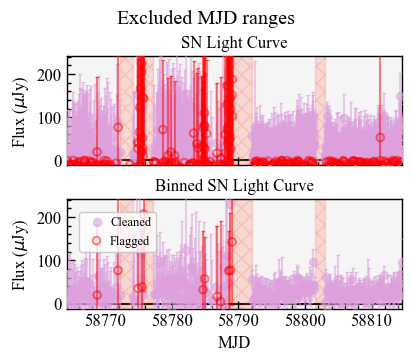

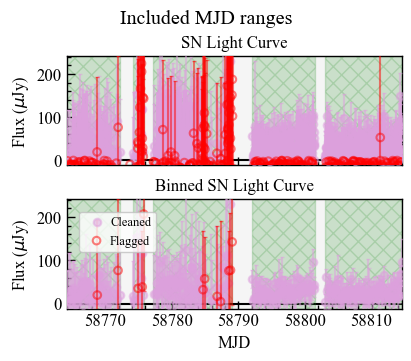

In [7]:
# ==== User Settings ====

# Optionally expand observation gap MJD ranges by +-exclude_obs_edges days on either side 
# (set to None or 0 to skip):
EXPAND_EDGES = 0

# Optionally exclude additional bad observation seasons or arbitrary ranges 
# (set to None or empty list [] to skip):
EXCLUDE_MJD_RANGES: List[List[int]] = [
    # [57233.0, TEMPLATE_CHANGE_1_MJD],
    # [TEMPLATE_CHANGE_2_MJD, 60771.0]
]

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

min_mjd, max_mjd = avg_sn.lcs[0].get_min_and_max_mjd()
print(f'Min MJD: {min_mjd}, max MJD: {max_mjd}')

print(f'Observation season ranges: {MJD_RANGES}')

excluded_mjd_ranges = get_inverse_mjd_ranges(
    MJD_RANGES, 
    min_mjd, 
    max_mjd, 
    expand_edges=EXPAND_EDGES,
    exclude_mjd_ranges=EXCLUDE_MJD_RANGES
)
print(f'Excluded MJD ranges (observation season gaps plus expanded edges and additional excluded ranges): \n\t{excluded_mjd_ranges}')

included_mjd_ranges = get_inverse_mjd_ranges(
    excluded_mjd_ranges, 
    min_mjd, 
    max_mjd
)
print(f"Included ranges: \n\t{included_mjd_ranges}")

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

if len(excluded_mjd_ranges) > 0:
    fig = p.plot_mjd_ranges(
        sn, 
        avg_sn, 
        config_flags,
        excluded_mjd_ranges,
        suptitle="Excluded MJD ranges",
        range_color="tomato",
        custom_lims=custom_lims,
        filename="excluded_mjd_ranges",
        save=SAVE_PLOTS
    )

if len(included_mjd_ranges) > 0:
    fig = p.plot_mjd_ranges(
        sn, 
        avg_sn, 
        config_flags,
        included_mjd_ranges,
        suptitle="Included MJD ranges",
        range_color="forestgreen",
        custom_lims=custom_lims,
        filename="included_mjd_ranges",
        save=SAVE_PLOTS
    )

### Calculate the preliminary range of valid detection limits $\Sigma_{\text{FOM, limit}}$

As our starting range of valid detection limits $\Sigma_{\text{FOM, limit}}$ for each $\sigma_{\text{kernel}}$, we set our lower limit to 0 and our upper limit to the maximum $\Sigma_{\text{FOM}}$ value across all control light curves.

In [8]:
# ==== User Settings ====

# Enter a list of possible sigma kernels (in days) of the weighted gaussian rolling sum:
SIGMA_KERNS = LogRangeParam(
    "sigma_kerns",
    0.125,
    3,
    10,
    5,
).values

# Exclude certain control lcs from the analysis 
# (set to None or empty list [] for no exclusions):
SKIP_CONTROL_INDICES = []

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

print(f"Skipping control light curves: {SKIP_CONTROL_INDICES}")
avg_sn.remove_lc_indices(SKIP_CONTROL_INDICES)

print(f'sigma_kerns: {SIGMA_KERNS}')
all_fom_dict, prelim_fom_limit_ranges = avg_sn.get_prelim_fom_limit_ranges(
    SIGMA_KERNS,
    included_mjd_ranges,
)

Creating parameter sigma_kerns
Generating 5-length float range using log base 10
Skipping control light curves: []
sigma_kerns: [0.12500000000000006, 0.2766704799250805, 0.6123724356957947, 1.3554030054147672, 3.0]
Calculating preliminary valid FOM limit ranges for sigma_kerns [0.12500000000000006, 0.2766704799250805, 0.6123724356957947, 1.3554030054147672, 3.0]...
Getting all control FOM for MJD ranges [[58764.0625, 58772.1875], [58774.1875, 58775.8125], [58777.1875, 58789.0625], [58792.0625, 58801.4375], [58803.0625, 58814.5625]]...
Valid FOM limit ranges: {0.12500000000000006: [0.0, 105.6], 0.2766704799250805: [0.0, 120.05], 0.6123724356957947: [0.0, 125.36], 1.3554030054147672: [0.0, 155.44], 3.0: [0.0, 223.04]}


### Calculate contamination for preliminary detection limits $\Sigma_{\text{FOM, limit}}$

In [9]:
contam = ContaminationTable()
contam.construct_prelim_t(
    avg_sn, 
    included_mjd_ranges, 
    SIGMA_KERNS, 
    prelim_fom_limit_ranges
)
print(contam)

Calculating preliminary contamination table for valid MJD ranges and preliminary FOM limit ranges...
Using preliminary FOM limit ranges: {0.12500000000000006: [0.0, 105.6], 0.2766704799250805: [0.0, 120.05], 0.6123724356957947: [0.0, 125.36], 1.3554030054147672: [0.0, 155.44], 3.0: [0.0, 223.04]}
Success
   sigma_kern  fom_limit  n_falsepos  n_pos_controls  pct_pos_controls  n_falsepos_00  n_falsepos_01  n_falsepos_02  n_falsepos_03  n_falsepos_04  n_falsepos_05  n_falsepos_06  n_falsepos_07  n_falsepos_08
0    0.125000       0.00          41               8             100.0              1              4              1              2              5              5             11              7              6
1    0.125000     105.60           0               0               0.0              0              0              0              0              0              0              0              0              0
2    0.276670       0.00          17               8             100.0      

### Plot $\Sigma_{\text{FOM}}$ and preliminary detection limits $\Sigma_{\text{FOM, limit}}$ for all $\sigma_{\text{kernel}}$

Applying rolling sum of sigma_kern=0.125 to all light curves...
Applying rolling sum of sigma_kern=0.27667 to all light curves...
Applying rolling sum of sigma_kern=0.61237 to all light curves...
Applying rolling sum of sigma_kern=1.3554 to all light curves...
Applying rolling sum of sigma_kern=3.0 to all light curves...


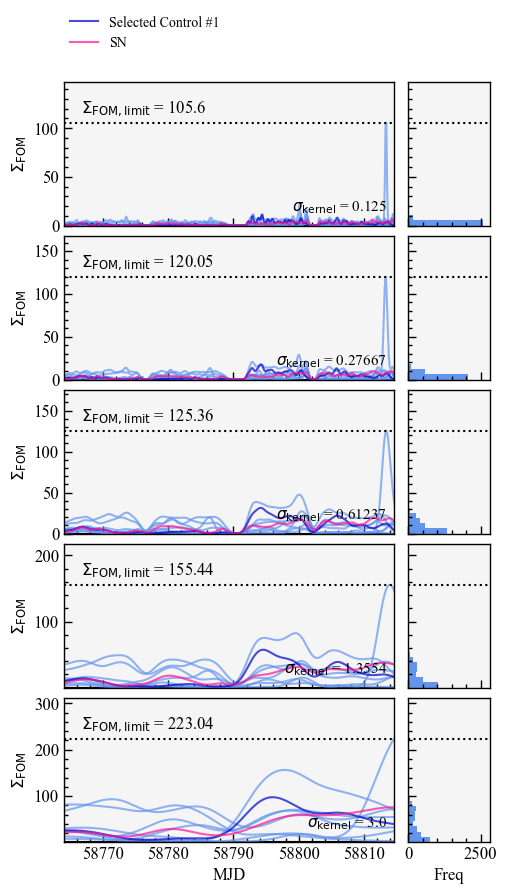

In [11]:
# ==== User Settings ====

# Enter the index of the control light curve to highlight:
SELECT_CONTROL_INDEX = 1

# =======================

fig = p.plot_fom(
    avg_sn, 
    all_fom_dict,
    SIGMA_KERNS, 
    SELECT_CONTROL_INDEX, 
    hexstring_to_int(config['averaging']['flag']),
    fom_limits={sigma_kern: fom_limits[1] for sigma_kern, fom_limits in prelim_fom_limit_ranges.items()},
    save=SAVE_PLOTS
)

### Calculate the best detection limits $\Sigma_{\text{FOM, limit}}$

We use the starting range of valid detection limits $\Sigma_{\text{FOM, limit}}$ and their corresponding contamination values to calculate the detection limit with the ideal contamination. Below, we allow the user to select the desired measure of contamination (i.e., the number of positive control light curves). 

We iterate for n_steps steps. If we have a starting range of detection limits $\Sigma_{\text{FOM, limit}}$ from $a$ to $b$ and iterate for $n$ steps, we obtain the detection limit with the desired contamination with an accuracy of $\frac{b-a}{2^n}$.

In [12]:
# ==== User Settings ====

# Enter the target contamination
# (i.e. the target number of positive control light curves for a given FOM limit):
TARGET_VALUE = 2

# Enter the maximum number of iterations for refining FOM limits:
N_STEPS = 15

# Load existing ContaminationTable from file
LOAD = False

# =======================

detec_tables_dir = get_detec_tables_output_dir(OUTPUT_DIR, TNSNAME)

if LOAD:
    contam.load(detec_tables_dir)
    print(contam)
    fom_limits = contam.get_fom_limits_from_t()
else:
    fom_limits = contam.calculate(
        avg_sn, 
        prelim_fom_limit_ranges, 
        included_mjd_ranges,
        SIGMA_KERNS,
        target_value=TARGET_VALUE,
        n_steps=N_STEPS,
        verbose=True
    )
    contam.save(detec_tables_dir)
# print(contam)
print(f"Best FOM limits for sigma_kerns: {fom_limits}")

Preliminary contamination table: 
   sigma_kern  fom_limit  n_falsepos  n_pos_controls  pct_pos_controls  n_falsepos_00  n_falsepos_01  n_falsepos_02  n_falsepos_03  n_falsepos_04  n_falsepos_05  n_falsepos_06  n_falsepos_07  n_falsepos_08
0    0.125000       0.00          41               8             100.0              1              4              1              2              5              5             11              7              6
1    0.125000     105.60           0               0               0.0              0              0              0              0              0              0              0              0              0
2    0.276670       0.00          17               8             100.0              1              1              1              1              1              3              4              2              4
3    0.276670     120.05           0               0               0.0              0              0              0              0            

### Plot the best detection limits $\Sigma_{\text{FOM, limit}}$

Applying rolling sum of sigma_kern=0.125 to all light curves...
Applying rolling sum of sigma_kern=0.27667 to all light curves...
Applying rolling sum of sigma_kern=0.61237 to all light curves...
Applying rolling sum of sigma_kern=1.3554 to all light curves...
Applying rolling sum of sigma_kern=3.0 to all light curves...


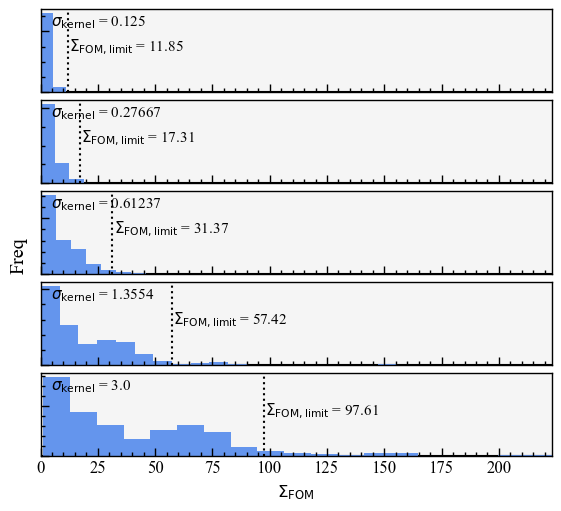

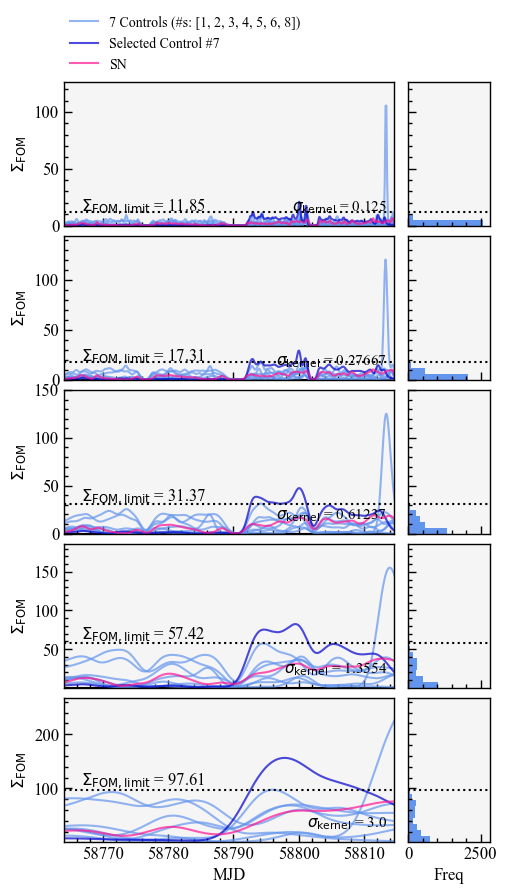

In [ ]:
fig = p.plot_fom_dists(SIGMA_KERNS, all_fom_dict, fom_limits)
fig.supylabel("Freq")

fig = p.plot_fom(
    avg_sn, 
    all_fom_dict,
    SIGMA_KERNS, 
    SELECT_CONTROL_INDEX, 
    hexstring_to_int(config['averaging']['flag']),
    fom_limits=fom_limits,
    save=SAVE_PLOTS
)

## Generate simulation tables using a predefined model and its parameters

In [17]:
# ==== User Settings ====

# Enter the name of the file with default parameter settings for possible simulation models:
SIM_SETTINGS_FILENAME = "simulation_settings.json"

# Enter the name of the model in SIM_SETTINGS_FILENAME to simulate:
MODEL = "gaussian"

# =======================

sim_config = load_json_config(SIM_SETTINGS_FILENAME)

if " " in MODEL:
    raise RuntimeError("Model name cannot have spaces.")
if MODEL not in sim_config:
    raise RuntimeError(
        f"Model '{MODEL}' not found in simulation config file\n"
        f"Available models: {', '.join(sim_config.keys())}"
    )
print(f"Loading settings for model '{MODEL}'...")
model_settings = sim_config[MODEL]

Loading JSON config file at simulation_settings.json...
Loading settings for model 'gaussian'...


### Option 1: Use a settings file like `simulation_settings.json`

In [19]:
print("Parsing model parameters...")
params = parse_params(
    model_settings,
    time_param_name=model_settings["time_parameter_name"],
    peak_appmag_param_name=model_settings["peak_appmag_parameter_name"],
)
filename, mjd_colname, mag_colname, flux_colname = parse_colname_info(
    model_settings, MODEL
)

Parsing model parameters...

Parsing config parameter peak_appmag:
Creating parameter peak_appmag (peak apparent magnitude param)
Result:  Parameter 'peak_appmag' (peak apparent magnitude param): [23.0, 22.63, 22.26, 21.89, 21.53, 21.16, 20.79, 20.42, 20.05, 19.68, 19.32, 18.95, 18.58, 18.21, 17.84, 17.47, 17.11, 16.74, 16.37, 16.0] (length: 20)

Parsing config parameter sigma_sim:
Creating parameter sigma_sim
Result:  Parameter 'sigma_sim': [5, 20, 40, 80, 100, 150, 200] (length: 7)

Parsing config parameter peak_mjd:
Creating parameter peak_mjd (time param)
Generating 500-length random list within the following valid ranges: [[57302, 57507], [57701, 57886], [58021, 58261], [58415, 58628], [58733, 58986], [59094, 59346], [59485, 59729], [59836, 60072], [60195, 60401]]
Making sure the time parameter 'peak_mjd' values match the MJDbin column format...
Result:  Parameter 'peak_mjd' (time param): [58884.5, 57425.5, 57881.5, 58733.5, 58786.5, ..., 58591.5, 58159.5, 59576.5, 58819.5, 58740.

### Option 2: Manually create `Param` objects

Create your parameter objects here, then add them to the `params` collection. Possible parameter objects include `ListParam`, `RangeParam`, `LogRangeParam`, `RandomParam`, `RandomInRangeParam`.

We have provided the code for Gaussian simulations below, as an example.

Remember to set `is_peak_appmag_param=True` for your peak apparent magnitude parameter, and `is_time_param=True` for your time parameter.

In [24]:
# ==== User Settings ====

# Enter the name of the model in SIM_SETTINGS_FILENAME to simulate:
MODEL = "gaussian"

# =======================

params = Params()

peak_appmag_param = RangeParam(
    "peak_appmag",
    minval = 16.0,
    maxval = 23.0,
    step = 0.5,
    is_peak_appmag_param=True
)
params.add(peak_appmag_param)

sigma_sim_param = LogRangeParam(
    "sigma_sim",
    minval = 5,
    maxval = 200,
    base = 10,
    n = 7,
    to_int = True
)
params.add(sigma_sim_param)

peak_mjd_param = RandomInRangeParam(
    "peak_mjd",
    included_mjd_ranges,
    10,
    is_time_param=True
)
params.add(peak_mjd_param)

params.validate()
print("\n",params)

Creating parameter peak_appmag (peak apparent magnitude param)
Setting to range from 16.0 to 23.0 with step size 0.5
Making sure the peak apparent magnitude parameter 'peak_appmag' values have up to 2 decimal places...
Creating parameter sigma_sim
Generating 7-length integer range using log base 10
Creating parameter peak_mjd (time param)
Generating 10-length random list within the following valid ranges: [[58418, 58487], [58594, 58837]]
Making sure the time parameter 'peak_mjd' values match the MJDbin column format...

 Params list (length 3): 
- Parameter 'peak_appmag' (peak apparent magnitude param): [16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5] (length: 14)
- Parameter 'sigma_sim': [5, 9, 17, 32, 58, 108, 200] (length: 7)
- Parameter 'peak_mjd' (time param): [58664.5, 58466.5, 58738.5, 58461.5, 58663.5, 58712.5, 58831.5, 58818.5, 58483.5, 58430.5] (length: 10)


### Generate simulation tables using the loaded *or* created `Param`s

In [25]:
sim_tables = SimTables(MODEL)
sim_tables.generate(
    params,
    filename=filename,
    mjd_colname=mjd_colname,
    mag_colname=mag_colname,
    flux_colname=flux_colname,
)
sim_tables_output_dir = get_sim_tables_output_dir(
    OUTPUT_DIR, TNSNAME
)
sim_tables.save_all(sim_tables_output_dir)


Generating 70-length SimTable for peak_appmag=16.0...
Generating 70-length SimTable for peak_appmag=16.5...
Generating 70-length SimTable for peak_appmag=17.0...
Generating 70-length SimTable for peak_appmag=17.5...
Generating 70-length SimTable for peak_appmag=18.0...
Generating 70-length SimTable for peak_appmag=18.5...
Generating 70-length SimTable for peak_appmag=19.0...
Generating 70-length SimTable for peak_appmag=19.5...
Generating 70-length SimTable for peak_appmag=20.0...
Generating 70-length SimTable for peak_appmag=20.5...
Generating 70-length SimTable for peak_appmag=21.0...
Generating 70-length SimTable for peak_appmag=21.5...
Generating 70-length SimTable for peak_appmag=22.0...
Generating 70-length SimTable for peak_appmag=22.5...
Success

Saving SimTables in directory: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm/bump_analysis/sim_tables
Success


- 400-day window between t1 and t2
- Zac will give me the SN with power law and subtraction, then can run that through the analysis
- TESS -> smaller bin size 
- Ask Zac about sigma kernels
- All front-facing functions should have extensive documentation